# Chapter 23 — Solar & Jupiter Radio Astronomy

The Sun is, by a wide margin, the **brightest radio source in the sky** — and
Jupiter is the only *planet* you can hear with a wire antenna in your backyard.
Both shout loudest in the **low-frequency, decametric** band around **20 MHz**,
which is exactly why they are the twin targets of [**NASA's Radio JOVE**
project](https://radiojove.gsfc.nasa.gov/): a build-it-yourself dual-dipole
antenna and an SDR that lets a student capture solar radio bursts and Jovian
storms with real, archivable data.

This chapter is the **science behind Radio JOVE**. We will:

- meet the Sun as an intense, *variable* radio source (Hey & Southworth, 1946);
- see why a **low** observing frequency probes **high** in the corona, through the
  **plasma frequency** $f_p \propto \sqrt{n_e}$ and a coronal density model;
- simulate a **type II burst** — the radio fingerprint of a coronal-mass-ejection
  (CME) shock — and *derive the shock speed* from its frequency drift;
- simulate **Jupiter's decametric (DAM)** emission, the Io-controlled storms that
  Radio JOVE was built to hear.

Everything runs **fully offline** on the base environment using simulation: the
physics lives in `jansky.solar`, and we add realistic noise with
`jansky.signals.rng`. No telescope, no network.

### Learning goals

By the end of this chapter you will be able to

- explain why the Sun and Jupiter are observed near **20 MHz**, and what part of
  the corona a given frequency samples;
- relate **electron density**, **plasma frequency**, and **height** in the corona
  with the Newkirk model;
- read a **dynamic spectrum** (frequency vs time waterfall) and recognise a
  frequency-drifting burst;
- turn a type II burst's **drift rate** into a **CME shock speed**, and understand
  how the assumed density model biases that number;
- describe Jovian **L-bursts** and **S-bursts** and the **Io–Jupiter** interaction.

This chapter connects back to **Chapter 16** (data formats): the spectrograms we
build here are exactly the *Radio-Sky Spectrograph* (`.sps`) products that the
Radio JOVE community archives and shares.


## 1. Orientation — the Sun (and a planet) burst onto the radio sky

Karl Jansky heard the **Milky Way**, not the Sun: in the early 1930s the Sun
happened to be near solar minimum and quiet. The Sun's radio debut came with
**World War II radar**. In February 1942, British radar operators were jammed by
a powerful noise source that turned out to be the Sun during an intense sunspot
group — work led by **J. S. Hey**, published once secrecy lifted as *"Solar
Radiations in the 4–6 Metre Radio Wave-Length Band"* (Hey 1946, **Nature 157,
47**). In parallel, **G. C. Southworth** had already detected the *quiet* Sun's
thermal **microwave** emission during the war (Southworth 1945, *J. Franklin
Inst.* **239, 285**). Together they revealed two faces of the radio Sun: a steady
thermal glow, and violent, sporadic **bursts** tied to flares and active regions.
See the [papers timeline](../docs/papers-timeline.md) for both, alongside Ryle &
Vonberg's 1946 first *interferometric* solar observations.

A decade later, **Burke & Franklin (1955**, *JGR* **60, 213**) stumbled on
intense bursts at 22.2 MHz that tracked with the rotation of **Jupiter** — the
first detection of radio emission from a **planet**, and the birth of planetary
radio astronomy.

### Why observe near 20 MHz?

A low frequency is not an accident — it is *forced* by the physics. A plasma
cannot transmit an electromagnetic wave below its **plasma frequency** $f_p$;
below $f_p$ the wave is reflected or absorbed. The corona's density (and so its
$f_p$) **falls with height**, so each observing frequency "sees down" only to the
layer where the local $f_p$ matches. Observe at **20 MHz** and you are probing the
corona a few solar radii out — and you are *below* Earth's ionospheric cutoff only
on good nights, which is its own amateur sport. This is Section 2.

### The solar burst zoo (types I–V), in one paragraph

Solar radio bursts are classified I–V by their appearance on a **dynamic
spectrum** (frequency vs time): **Type I** — long-lived noise storms of many short
bursts over active regions; **Type II** — *slow* frequency drift (minutes), the
signature of a **shock** (often a CME) climbing through the corona; **Type III** —
*fast* drift (seconds), beams of electrons streaming outward along open field
lines; **Type IV** — broadband continuum from a moving or stationary plasmoid
after a flare; **Type V** — short continuum sometimes following type III. The star
of this chapter is the **type II**: because its drift is slow and tied to a
physical shock moving through a known density profile, you can *measure the
shock's speed* — "low-hanging real science" with a ~1 m antenna (see the
[field notes](../docs/field-notes.md)).


## Setup

We import the **plasma / coronal-density toolkit** from `jansky.solar` and the
course plotting style. We **do not re-implement** the plasma-frequency relation,
the Newkirk density model, or the burst-drift forward/inverse calculation —
every numerical step below calls a helper from that module. We seed every random
draw with `jansky.signals.rng` so the chapter is reproducible.

The helpers we use:

- `plasma_frequency(n_e)` — electron plasma frequency $f_p$ [MHz] from density
  [cm$^{-3}$];
- `density_from_plasma_frequency(f)` — its inverse;
- `newkirk_density(r, fold)` — Newkirk (1961) coronal density at heliocentric
  radius $r$ [solar radii];
- `newkirk_radius(n_e, fold)` — inverse Newkirk: radius for a density;
- `type_ii_track(speed, ...)` — forward-model a type II's frequency-time drift;
- `shock_speed_from_track(times, freqs, ...)` — recover the shock speed from a
  drift;
- `R_SUN_KM` — the solar radius in km.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from jansky.plotting import use_jansky_style, show_image
from jansky.signals import rng
from jansky.solar import (
    R_SUN_KM,
    plasma_frequency,
    density_from_plasma_frequency,
    newkirk_density,
    newkirk_radius,
    type_ii_track,
    shock_speed_from_track,
)

use_jansky_style()
SEED = 23
generator = rng(SEED)  # one seeded generator for the whole chapter

print(f"solar radius R_sun = {R_SUN_KM:,.0f} km = {(R_SUN_KM * u.km).to(u.Rsun):.3f}")
print(f"plasma frequency at n_e = 1e8 cm^-3 : {plasma_frequency(1e8):.1f} MHz")

solar radius R_sun = 695,700 km = 1.000 solRad
plasma frequency at n_e = 1e8 cm^-3 : 89.8 MHz


## 2. Plasma frequency & the corona

The key relation for *everything* in this chapter is the **electron plasma
frequency**: the natural oscillation frequency of a cloud of free electrons,

$$
f_p \;=\; \frac{1}{2\pi}\sqrt{\frac{n_e\,e^2}{\varepsilon_0\,m_e}}
\;\approx\; 8.98\times10^{-3}\,\sqrt{n_e\,[\mathrm{cm^{-3}}]}\ \ \mathrm{MHz}.
$$

The headline is the **square-root**: $f_p \propto \sqrt{n_e}$. A plasma is opaque
to waves below $f_p$, so the radio emission we receive at frequency $\nu$ was
generated where the local plasma frequency is $\nu$ (the *fundamental*) or
$\nu/2$ (the *harmonic*, $2 f_p$). To turn frequency into **height**, we need how
density falls with height — the **Newkirk (1961)** coronal model,

$$
n_e(r) \;=\; f \cdot 4.2\times10^{4}\;\,10^{\,4.32/r}\ \ \mathrm{cm^{-3}},
$$

with $r$ in **solar radii from Sun centre**. The fold factor $f$ (1–4) scales the
model up for denser streamers and active regions. Putting the two together gives
$f_p(r)$: a curve that falls steeply with height. **Low frequency ⇒ high in the
corona.** Let us plot all three.


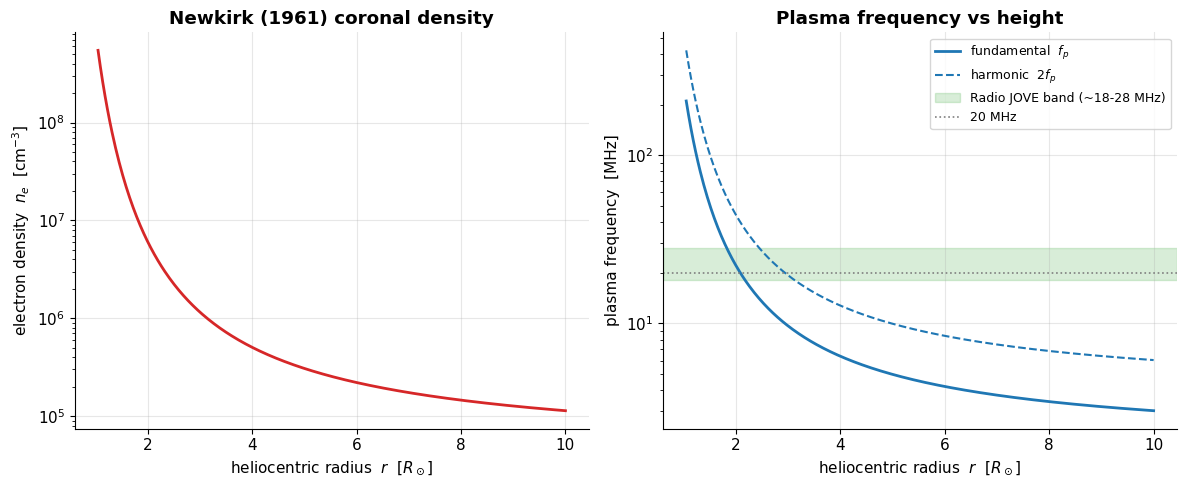

In [2]:
# Heliocentric radius grid, from just above the surface to ~10 solar radii.
r = np.linspace(1.05, 10.0, 400)          # [solar radii]
n_e = newkirk_density(r, fold=1.0)        # [cm^-3]
fp = plasma_frequency(n_e)                # fundamental plasma frequency [MHz]

# Common observing references. The Sun emits at the FUNDAMENTAL (f_p) and the
# HARMONIC (2 f_p); the height a band probes depends on which you assume.
jove_band = (18.0, 28.0)   # Radio JOVE listens over ~8 MHz around ~20-24 MHz
f_20 = 20.0                # a round "metre-wave" reference

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) density vs height
axes[0].semilogy(r, n_e, color="#d62728", lw=2)
axes[0].set_xlabel("heliocentric radius  $r$  [$R_\\odot$]")
axes[0].set_ylabel("electron density  $n_e$  [cm$^{-3}$]")
axes[0].set_title("Newkirk (1961) coronal density")

# (b) plasma frequency vs height, with observing bands marked
axes[1].semilogy(r, fp, color="#1f77b4", lw=2, label="fundamental  $f_p$")
axes[1].semilogy(r, 2 * fp, color="#1f77b4", lw=1.5, ls="--",
                 label="harmonic  $2 f_p$")
axes[1].axhspan(*jove_band, color="#2ca02c", alpha=0.18,
                label="Radio JOVE band (~18-28 MHz)")
axes[1].axhline(f_20, color="#7f7f7f", ls=":", lw=1.2, label="20 MHz")
axes[1].set_xlabel("heliocentric radius  $r$  [$R_\\odot$]")
axes[1].set_ylabel("plasma frequency  [MHz]")
axes[1].set_title("Plasma frequency vs height")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Where does 20 MHz come from?** Invert the model: find the height at which the
fundamental (and the harmonic) plasma frequency equals our observing references.
This is `newkirk_radius` composed with `density_from_plasma_frequency`.


In [3]:
def height_of_frequency(f_mhz, harmonic=1, fold=1.0):
    "Heliocentric radius (R_sun) at which emission at f_mhz originates."
    f_p = np.asarray(f_mhz, dtype=float) / harmonic
    n_e = density_from_plasma_frequency(f_p)
    return newkirk_radius(n_e, fold=fold)

for f in (20.0, 24.0, 80.0):
    r_fund = height_of_frequency(f, harmonic=1)
    r_harm = height_of_frequency(f, harmonic=2)
    print(f"{f:5.0f} MHz  ->  fundamental from r = {r_fund:.2f} R_sun, "
          f"harmonic (2 f_p) from r = {r_harm:.2f} R_sun")

print()
print("So 20 MHz fundamental emission is born around "
      f"{height_of_frequency(20.0):.1f} solar radii out -- well up in the corona,")
print("which is why low frequency = high altitude. A 200 MHz burst, by contrast,")
print(f"comes from r = {height_of_frequency(200.0):.2f} R_sun -- right down near the surface.")

   20 MHz  ->  fundamental from r = 2.08 R_sun, harmonic (2 f_p) from r = 2.94 R_sun
   24 MHz  ->  fundamental from r = 1.94 R_sun, harmonic (2 f_p) from r = 2.65 R_sun
   80 MHz  ->  fundamental from r = 1.32 R_sun, harmonic (2 f_p) from r = 1.62 R_sun

So 20 MHz fundamental emission is born around 2.1 solar radii out -- well up in the corona,
which is why low frequency = high altitude. A 200 MHz burst, by contrast,
comes from r = 1.06 R_sun -- right down near the surface.


Notice the asymmetry the square-root creates: density spans **orders of
magnitude** from the low corona to a few $R_\odot$, but plasma frequency, going as
$\sqrt{n_e}$, falls more gently. A *factor-of-100* drop in density is only a
*factor-of-10* drop in $f_p$. That is what lets a single ~8 MHz-wide receiver,
parked near 20 MHz, watch a disturbance climb across a real swath of the corona —
the engine of the type II measurement in Section 3.


## 3. A type II burst → a CME shock speed

Now the payoff. A **coronal mass ejection** drives a **shock** outward through the
corona. At the shock front, electrons are accelerated and the local plasma rings
at its plasma frequency, radiating at $f_p$ and $2 f_p$. As the shock **climbs**,
the density (and so $f_p$) **drops**, so the emission **drifts down in frequency**.
That slow downward drift on the dynamic spectrum *is* the type II burst.

`type_ii_track(speed_km_s, r_start, harmonic, fold)` forward-models exactly this:
a shock moving radially at constant speed from `r_start`, emitting at
`harmonic`$\times f_p$ at each height, using the Newkirk density. We pick a CME
shock at **700 km/s** — a fairly typical value — starting at $1.5\,R_\odot$ and
emitting at the **harmonic** ($2 f_p$), and read off its frequency-time track.


In [4]:
V_TRUE = 700.0       # true CME shock speed [km/s]
R_START = 1.5        # shock launches at 1.5 solar radii
HARMONIC = 2         # observe the harmonic band (2 f_p)
DURATION = 600.0     # 10 minutes of drift

times, freqs = type_ii_track(
    V_TRUE, r_start=R_START, duration_s=DURATION, harmonic=HARMONIC, fold=1.0,
)

print(f"Type II track for a {V_TRUE:.0f} km/s shock from r = {R_START} R_sun:")
print(f"  starts at {freqs[0]:.1f} MHz, drifts down to {freqs[-1]:.1f} MHz "
      f"over {DURATION/60:.0f} min")
drift = (freqs[0] - freqs[-1]) / DURATION
print(f"  mean drift rate: {-drift*1e3:.2f} kHz/s "
      f"(slow -- the hallmark of a type II)")

Type II track for a 700 km/s shock from r = 1.5 R_sun:
  starts at 101.3 MHz, drifts down to 39.1 MHz over 10 min
  mean drift rate: -103.68 kHz/s (slow -- the hallmark of a type II)


### Make it look like real data: a dynamic spectrum with noise

A receiver does not hand you a clean curve; it hands you a **waterfall** — power
in each (time, frequency) pixel, mostly noise, with the burst a bright ridge
tracing the track. We paint the track onto a noisy time–frequency grid with a
Gaussian profile in frequency, exactly as `signals.synthetic_spectrum` adds
Gaussian noise elsewhere in the course.


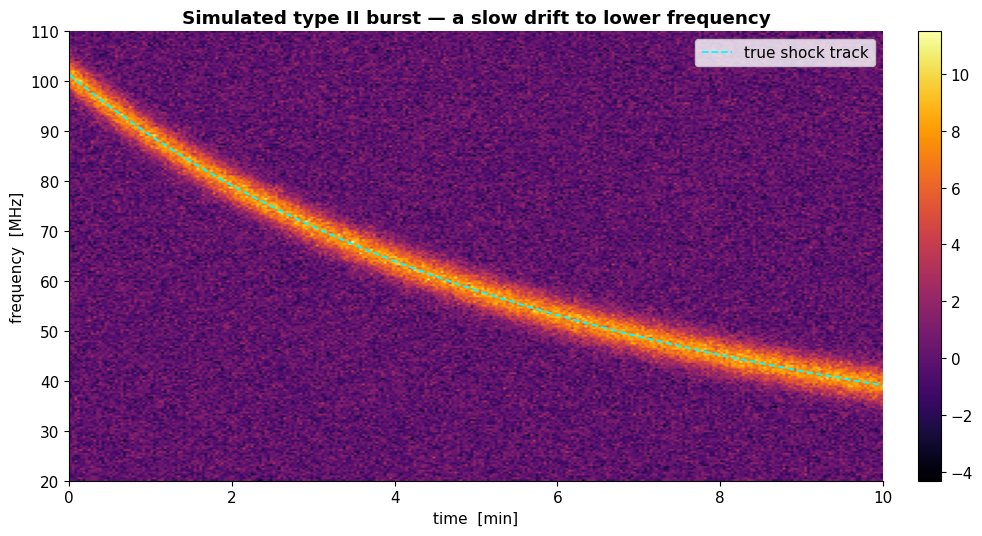

In [5]:
# Build a (frequency, time) dynamic spectrum around the burst's band.
f_axis = np.linspace(20.0, 110.0, 240)     # MHz (receiver passband)
t_axis = np.linspace(0.0, DURATION, 300)   # s

# Interpolate the burst's frequency at each time sample.
f_burst = np.interp(t_axis, times, freqs)

# Start from thermal noise, then add a Gaussian-in-frequency ridge at f_burst(t).
dynspec = generator.normal(0.0, 1.0, size=(f_axis.size, t_axis.size))
ridge_width = 2.5   # MHz, the burst's instantaneous bandwidth
amplitude = 8.0     # peak in units of the noise sigma
FF, _ = np.meshgrid(f_axis, t_axis, indexing="ij")
dynspec += amplitude * np.exp(-0.5 * ((FF - f_burst[None, :]) / ridge_width) ** 2)

fig, ax = plt.subplots(figsize=(10, 5.5))
extent = [0.0, DURATION / 60.0, f_axis[0], f_axis[-1]]  # x=min, y=MHz
show_image(dynspec, ax=ax, aspect="auto", extent=extent,
           title="Simulated type II burst — a slow drift to lower frequency")
ax.plot(times / 60.0, freqs, color="cyan", lw=1.3, ls="--",
        label="true shock track")
ax.set_xlabel("time  [min]")
ax.set_ylabel("frequency  [MHz]")
ax.grid(False)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Recover the shock speed

This is the science. The drift rate encodes the shock's speed *through the density
gradient*. `shock_speed_from_track` inverts the whole chain: each observed
frequency → plasma frequency (÷ harmonic) → density → height (Newkirk) → a
straight-line fit of **height vs time**, whose slope is the radial speed. We feed
it the burst track *as if we had measured it from the waterfall* and compare to
the true input.


In [6]:
v_recovered = shock_speed_from_track(times, freqs, harmonic=HARMONIC, fold=1.0)

print(f"true shock speed       : {V_TRUE:.0f} km/s")
print(f"recovered shock speed  : {v_recovered:.0f} km/s")
print(f"error                  : {100*(v_recovered - V_TRUE)/V_TRUE:+.2f} %")
print()
print("With the SAME density model and harmonic we used to make the burst, the")
print("recovery is essentially exact -- the method is self-consistent. Real life")
print("is messier: you must ASSUME a coronal model, and that assumption bites.")

true shock speed       : 700 km/s
recovered shock speed  : 700 km/s
error                  : -0.00 %

With the SAME density model and harmonic we used to make the burst, the
recovery is essentially exact -- the method is self-consistent. Real life
is messier: you must ASSUME a coronal model, and that assumption bites.


Let us see the inversion geometrically: convert the track to **height vs time**
and confirm it is a straight line whose slope is the speed.


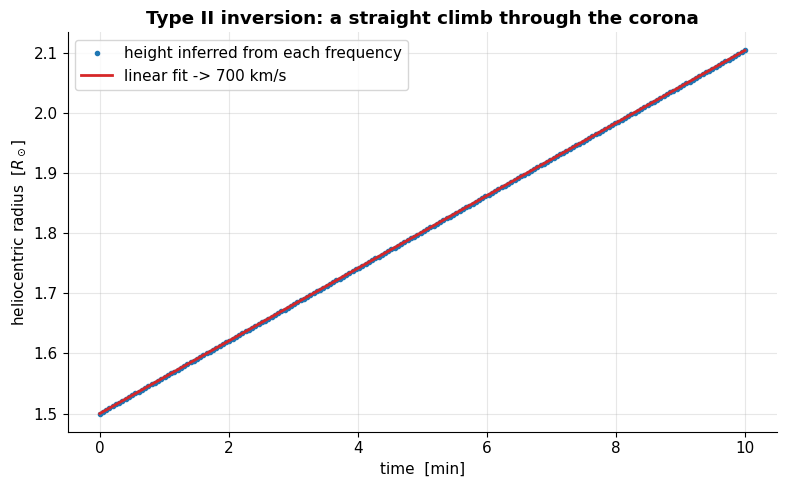

In [7]:
# Reproduce the inversion by hand to visualise it.
f_p = freqs / HARMONIC
n_e_track = density_from_plasma_frequency(f_p)
r_track = newkirk_radius(n_e_track)                 # solar radii
slope, intercept = np.polyfit(times, r_track, 1)    # R_sun / s
v_fit = slope * R_SUN_KM                             # km/s

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(times / 60.0, r_track, "o", ms=3, color="#1f77b4",
        label="height inferred from each frequency")
ax.plot(times / 60.0, (intercept + slope * times), color="#d62728", lw=2,
        label=f"linear fit -> {v_fit:.0f} km/s")
ax.set_xlabel("time  [min]")
ax.set_ylabel("heliocentric radius  [$R_\\odot$]")
ax.set_title("Type II inversion: a straight climb through the corona")
ax.legend()
plt.tight_layout()
plt.show()

**Typical CME speeds** run from a leisurely ~250 km/s up to the fastest
Earth-directed events at **2000+ km/s**; the fastest can reach Earth in under a
day and drive geomagnetic storms. The type II's drift rate is one of the few ways
to estimate the shock speed *while it is still in the corona*, from the ground, at
amateur frequencies. Let us confirm faster shocks drift faster.


In [8]:
print(f"{'V_in [km/s]':>12} {'start MHz':>10} {'end MHz':>9} "
      f"{'drift kHz/s':>12} {'V_out [km/s]':>13}")
for v_in in (300.0, 700.0, 1200.0, 2000.0):
    t_k, f_k = type_ii_track(v_in, r_start=R_START, duration_s=DURATION,
                             harmonic=HARMONIC)
    drift_rate = -(f_k[-1] - f_k[0]) / DURATION * 1e3   # kHz/s
    v_out = shock_speed_from_track(t_k, f_k, harmonic=HARMONIC)
    print(f"{v_in:12.0f} {f_k[0]:10.1f} {f_k[-1]:9.1f} "
          f"{drift_rate:12.2f} {v_out:13.0f}")

 V_in [km/s]  start MHz   end MHz  drift kHz/s  V_out [km/s]
         300      101.3      62.2        65.20           300
         700      101.3      39.1       103.68           700
        1200      101.3      26.2       125.28          1200
        2000      101.3      17.2       140.23          2000


### The density model is an assumption — and it biases the speed

The catch the field notes warned about: you never *know* the coronal density;
you **assume a model**. If the real corona is denser than you think (a streamer,
an active region — a larger `fold`), but you invert with `fold=1`, your inferred
heights are wrong and so is your speed. Below we *generate* a burst in a corona
that is **3× denser** (`fold=3`, e.g. a dense streamer) but **analyse** it with
the default `fold=1`, and watch the recovered speed go astray.


In [9]:
# Truth: a 700 km/s shock in a DENSE (fold=3) corona.
t_dense, f_dense = type_ii_track(V_TRUE, r_start=R_START, duration_s=DURATION,
                                 harmonic=HARMONIC, fold=3.0)

# Analyst's choices: the correct fold vs the (wrong) default fold=1.
v_correct = shock_speed_from_track(t_dense, f_dense, harmonic=HARMONIC, fold=3.0)
v_wrongfold = shock_speed_from_track(t_dense, f_dense, harmonic=HARMONIC, fold=1.0)

# And: what if you mistake the harmonic band for the fundamental?
v_wrongharm = shock_speed_from_track(t_dense, f_dense, harmonic=1, fold=3.0)

print(f"true speed                                  : {V_TRUE:.0f} km/s")
print(f"recovered with CORRECT model (fold=3, h=2)  : {v_correct:.0f} km/s")
print(f"recovered assuming WRONG density (fold=1)   : {v_wrongfold:.0f} km/s "
      f"({100*(v_wrongfold-V_TRUE)/V_TRUE:+.0f}%)")
print(f"recovered assuming WRONG harmonic (h=1)     : {v_wrongharm:.0f} km/s "
      f"({100*(v_wrongharm-V_TRUE)/V_TRUE:+.0f}%)")
print()
print("Density fold and harmonic both rescale the inferred heights; a wrong")
print("choice systematically biases the speed. Real type II analyses quote the")
print("coronal model used precisely because the answer depends on it.")

true speed                                  : 700 km/s
recovered with CORRECT model (fold=3, h=2)  : 700 km/s
recovered assuming WRONG density (fold=1)   : 487 km/s (-30%)
recovered assuming WRONG harmonic (h=1)     : 448 km/s (-36%)

Density fold and harmonic both rescale the inferred heights; a wrong
choice systematically biases the speed. Real type II analyses quote the
coronal model used precisely because the answer depends on it.


## 4. Jupiter's decametric (DAM) emission

Switch targets. **Jupiter** is a strong, sporadic source of **decametric (DAM)**
radio emission — wavelengths of tens of metres, i.e. **frequencies up to ~40 MHz**
with most activity below ~30 MHz. It is generated by the **cyclotron maser
instability**: electrons spiralling along Jupiter's enormous magnetic field near
its poles radiate coherently. Crucially, much of the emission is **controlled by
Io**: the volcanic moon ploughs through Jupiter's magnetosphere, and the
**Io–Jupiter flux tube** of current it sets up modulates the storms. Whether you
hear Jupiter depends on the **System III longitude** (which way the magnetic field
points) *and* on **Io's orbital phase** — the famous "Io-A/B/C" storm regions.

On a dynamic spectrum the storms show two characteristic features:

- **L-bursts ("long")** — smooth, second-to-minute-scale rises and falls; on an
  SDR they sound like ocean waves washing in and out;
- **S-bursts ("short")** — millisecond crackles that drift rapidly in frequency;
  they sound like popcorn or a crackling fire.

Both live in the **same ~18–28 MHz band Radio JOVE listens to**. Let us simulate a
Jovian storm spectrogram with pure NumPy — no new helper needed — by laying
L-burst blobs and fast-drifting S-burst streaks onto a noisy time–frequency grid.


In [10]:
# Jovian DAM spectrogram: 6 minutes over the Radio JOVE band.
f_jove = np.linspace(16.0, 30.0, 280)       # MHz
t_jove = np.linspace(0.0, 360.0, 1400)      # s  (fine sampling for S-bursts)
JJ, TT = np.meshgrid(f_jove, t_jove, indexing="ij")  # (freq, time)

jov = generator.normal(0.0, 1.0, size=(f_jove.size, t_jove.size))  # noise floor

# --- L-bursts: broadband, smooth, tens-of-seconds envelopes -----------------
def add_lburst(grid, t0, dur, f_lo, f_hi, amp):
    "Smooth broadband swell centred at time t0."
    t_env = np.exp(-0.5 * ((TT - t0) / (dur / 2.355)) ** 2)
    f_env = ((JJ > f_lo) & (JJ < f_hi)).astype(float)
    # soften the band edges
    f_env = np.clip(f_env + 0.4 * np.exp(-0.5 * ((JJ - 0.5*(f_lo+f_hi)) / 4.0)**2), 0, 1)
    grid += amp * t_env * f_env

for t0, dur, flo, fhi, amp in [
    (70.0, 40.0, 18.0, 27.0, 4.0),
    (150.0, 55.0, 17.0, 24.0, 3.0),
    (250.0, 35.0, 20.0, 29.0, 4.5),
]:
    add_lburst(jov, t0, dur, flo, fhi, amp)

# --- S-bursts: fast NEGATIVE frequency drift, millisecond crackles ----------
s_generator = rng(SEED + 1)
n_sbursts = 240
drift_mhz_per_s = -25.0    # S-bursts drift down ~ -10 to -40 MHz/s
for _ in range(n_sbursts):
    ts = s_generator.uniform(20.0, 340.0)     # onset time [s]
    fs = s_generator.uniform(22.0, 29.0)      # onset frequency [MHz]
    life = s_generator.uniform(0.05, 0.4)     # duration [s]
    amp = s_generator.uniform(5.0, 9.0)
    f_of_t = fs + drift_mhz_per_s * (TT - ts)
    mask = (TT >= ts) & (TT <= ts + life)
    jov += amp * mask * np.exp(-0.5 * ((JJ - f_of_t) / 0.35) ** 2)

print(f"Jovian spectrogram: {jov.shape[0]} channels x {jov.shape[1]} time samples")
print(f"  {3} L-burst swells + {n_sbursts} S-burst crackles over "
      f"{t_jove[-1]/60:.0f} min, all in the {f_jove[0]:.0f}-{f_jove[-1]:.0f} MHz JOVE band")

Jovian spectrogram: 280 channels x 1400 time samples
  3 L-burst swells + 240 S-burst crackles over 6 min, all in the 16-30 MHz JOVE band


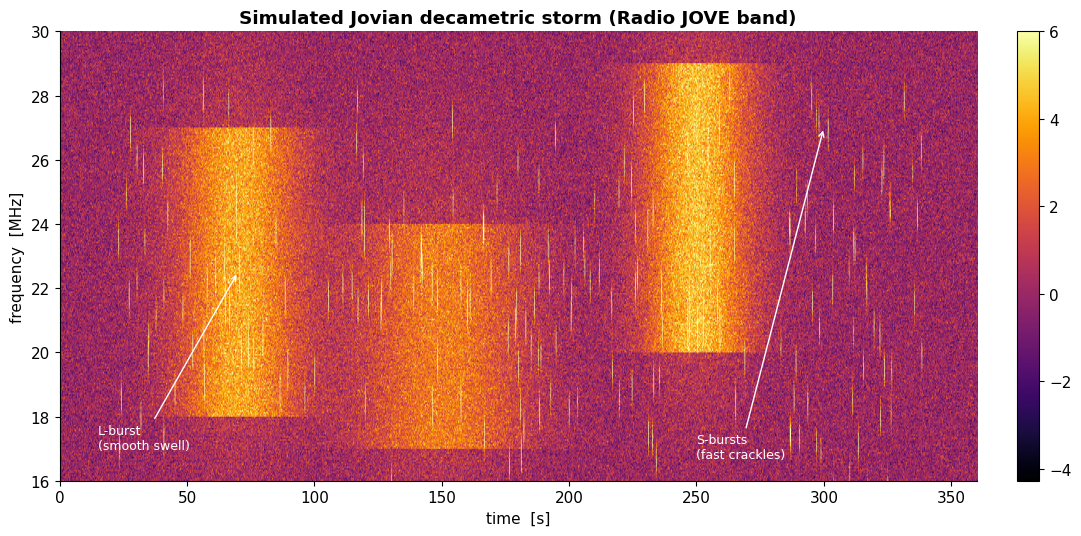

In [11]:
fig, ax = plt.subplots(figsize=(11, 5.5))
extent = [0.0, t_jove[-1], f_jove[0], f_jove[-1]]
show_image(jov, ax=ax, aspect="auto", extent=extent, vmax=6.0,
           title="Simulated Jovian decametric storm (Radio JOVE band)")
ax.set_xlabel("time  [s]")
ax.set_ylabel("frequency  [MHz]")
ax.grid(False)
# Annotate the two burst types.
ax.annotate("L-burst\n(smooth swell)", xy=(70, 22.5), xytext=(15, 17.0),
            color="white", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white"))
ax.annotate("S-bursts\n(fast crackles)", xy=(300, 27.0), xytext=(250, 16.7),
            color="white", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white"))
plt.tight_layout()
plt.show()

Zoom into one second to see the **S-bursts** resolve into individual
fast-drifting streaks — the millisecond fine structure that needs a fast,
wide-bandwidth receiver to catch (and whose physics is still not fully settled).


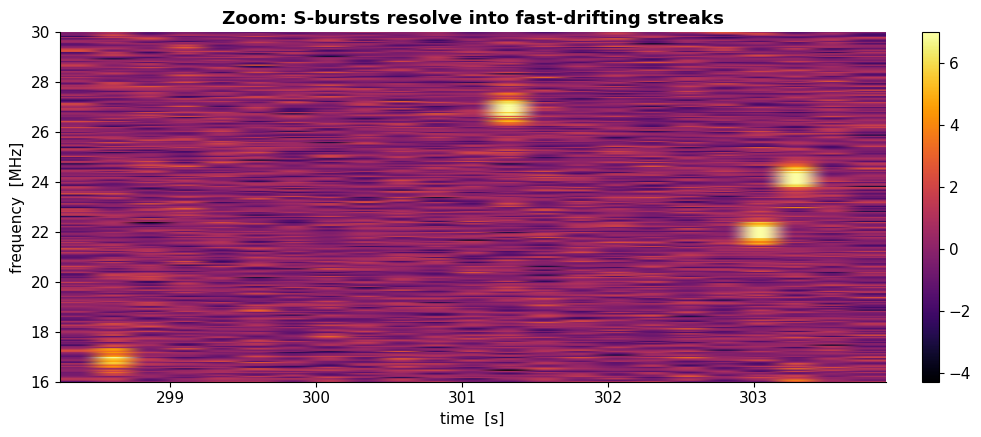

In [12]:
# Zoom: a 1.5 s window rich in S-bursts.
tmask = (t_jove >= 298.0) & (t_jove <= 304.0)
fig, ax = plt.subplots(figsize=(10, 4.5))
extent_zoom = [t_jove[tmask][0], t_jove[tmask][-1], f_jove[0], f_jove[-1]]
show_image(jov[:, tmask], ax=ax, aspect="auto", extent=extent_zoom, vmax=7.0,
           title="Zoom: S-bursts resolve into fast-drifting streaks")
ax.set_xlabel("time  [s]")
ax.set_ylabel("frequency  [MHz]")
ax.grid(False)
plt.tight_layout()
plt.show()

**What a Radio JOVE station actually detects.** A Radio JOVE kit is a pair of
half-wave dipoles strung between poles (a *phased dual-dipole* aimed at the
meridian) feeding an **SDRplay RSP1B** SDR, recording an ~8 MHz band around
20–24 MHz with **Radio-Sky Spectrograph** software. Point it on a night when
Jupiter is up and Io is in an active phase, and the waterfall you record looks
much like the figures above: L-burst swells and S-burst crackles riding on the
galactic background. The same station catches **solar type III and type II bursts**
by day. See [Projects, Kits & Hacks](../docs/projects.md) for the kit, and
[Chapter 16](16_data_formats_and_ecosystem.ipynb) for the `.sps` file format these
spectrograms are saved and shared in.


## 5. Try it yourself

These all reuse `jansky.solar`; copy a cell above and change the marked values.

### Exercise 1 — A different CME

Re-run the type II analysis for a **fast** CME, say **1500 km/s**, and a **slow**
one, **350 km/s**. For each, (a) make the track with `type_ii_track`, (b) recover
the speed with `shock_speed_from_track`, and (c) report the mean drift rate in
kHz/s. Which drifts out of the band first? *(Hint: the cell below is a starting
point.)*


In [13]:
# TODO: try other speeds, and add your own. Then plot drift rate vs speed.
for v in (350.0, 1500.0):
    t_x, f_x = type_ii_track(v, r_start=1.5, duration_s=600.0, harmonic=2)
    v_back = shock_speed_from_track(t_x, f_x, harmonic=2)
    rate = -(f_x[-1] - f_x[0]) / 600.0 * 1e3
    print(f"V_in {v:6.0f} km/s -> recovered {v_back:6.0f} km/s, "
          f"drift {rate:5.2f} kHz/s, band {f_x[0]:.1f}->{f_x[-1]:.1f} MHz")

V_in    350 km/s -> recovered    350 km/s, drift 71.98 kHz/s, band 101.3->58.2 MHz
V_in   1500 km/s -> recovered   1500 km/s, drift 132.53 kHz/s, band 101.3->21.8 MHz


### Exercise 2 — Where did the shock start, and how dense?

Vary **`r_start`** (e.g. 1.2, 1.5, 2.0 $R_\odot$): a shock launched lower starts at
a *higher* frequency. Then vary the **density `fold`** used to *generate* the burst
while keeping the analysis at `fold=1`, and quantify the resulting speed bias as a
percentage. How big a `fold` error gives a 25% speed error?


In [14]:
# TODO: scan r_start and the generate/analyse fold mismatch.
print("r_start scan (V=700, fold=1, harmonic=2):")
for rs in (1.2, 1.5, 2.0):
    _, f_rs = type_ii_track(700.0, r_start=rs, harmonic=2)
    print(f"  r_start={rs} R_sun -> burst spans {f_rs[0]:.1f} -> {f_rs[-1]:.1f} MHz")

print("\\nfold-mismatch scan (true fold varies; analysed with fold=1):")
for true_fold in (1.0, 2.0, 3.0, 4.0):
    t_m, f_m = type_ii_track(700.0, r_start=1.5, harmonic=2, fold=true_fold)
    v_m = shock_speed_from_track(t_m, f_m, harmonic=2, fold=1.0)
    print(f"  true fold={true_fold} -> recovered {v_m:6.0f} km/s "
          f"({100*(v_m-700)/700:+.0f}%)")

r_start scan (V=700, fold=1, harmonic=2):
  r_start=1.2 R_sun -> burst spans 232.2 -> 58.0 MHz
  r_start=1.5 R_sun -> burst spans 101.3 -> 39.1 MHz
  r_start=2.0 R_sun -> burst spans 44.2 -> 24.9 MHz
\nfold-mismatch scan (true fold varies; analysed with fold=1):
  true fold=1.0 -> recovered    700 km/s (-0%)
  true fold=2.0 -> recovered    553 km/s (-21%)
  true fold=3.0 -> recovered    487 km/s (-30%)
  true fold=4.0 -> recovered    448 km/s (-36%)


### Exercise 3 — Design a Jupiter storm

Build your own Jovian spectrogram (copy the Section 4 cells): change the
**S-burst drift rate** (`drift_mhz_per_s`, try $-10$ to $-40$ MHz/s), the **number
of S-bursts**, and the **L-burst timings**, to mimic an *Io-B* storm (intense,
S-burst-rich) versus a quieter *non-Io* event. Add a slowly varying galactic
background by replacing the flat noise floor with one that ramps with time.


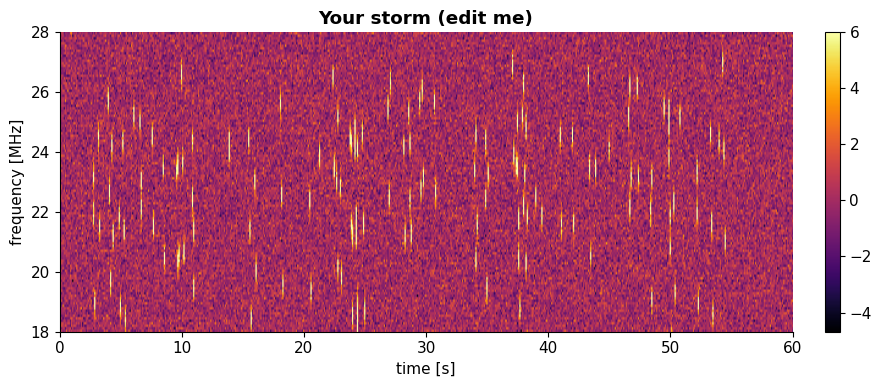

In [15]:
# TODO: your storm. Starter: an S-burst-rich "Io-B"-like burst train.
demo = rng(SEED + 7).normal(0.0, 1.0, size=(120, 600))
fdemo = np.linspace(18.0, 28.0, 120)
tdemo = np.linspace(0.0, 60.0, 600)
Fd, Td = np.meshgrid(fdemo, tdemo, indexing="ij")
g = rng(SEED + 8)
for _ in range(80):
    ts, fs, life = g.uniform(2, 55), g.uniform(24, 27.5), g.uniform(0.05, 0.3)
    f_of_t = fs - 30.0 * (Td - ts)
    demo += 7.0 * ((Td >= ts) & (Td <= ts + life)) * \
        np.exp(-0.5 * ((Fd - f_of_t) / 0.3) ** 2)
fig, ax = plt.subplots(figsize=(9, 4))
show_image(demo, ax=ax, aspect="auto", vmax=6.0,
           extent=[0, 60, 18, 28], title="Your storm (edit me)")
ax.set_xlabel("time [s]"); ax.set_ylabel("frequency [MHz]"); ax.grid(False)
plt.tight_layout(); plt.show()

## Recap

- The **Sun** is the sky's brightest radio source — a steady thermal glow
  (Southworth 1945) plus violent **bursts** (Hey 1946) — and **Jupiter** is the
  only planet you can hear with a wire (Burke & Franklin 1955). Both peak in the
  **decametric** band near **20 MHz**.
- A plasma is opaque below its **plasma frequency**, $f_p \propto \sqrt{n_e}$. The
  corona thins with height, so **low frequency ⇒ high in the corona** — 20 MHz
  emission is born a few solar radii out. The **Newkirk** model ties density,
  $f_p$, and height together.
- **Type II bursts** are the radio signature of a **CME shock** climbing the
  corona; their slow downward **frequency drift** plus a density model gives the
  **shock speed**. With a self-consistent model the recovery is exact; in practice
  the assumed **density fold** and **harmonic** systematically **bias** the answer
  — which is why papers always state the coronal model used. Typical CMEs run from
  ~250 to **2000+ km/s**.
- **Jupiter's DAM** emission (cyclotron maser, Io-controlled) appears as smooth
  **L-bursts** and fast-crackling **S-bursts** in the *same* ~18–28 MHz band — the
  signal a **Radio JOVE** dual-dipole + SDR records.
- This is real, low-cost science: see the [field notes](../docs/field-notes.md) on
  solar bursts as "low-hanging" amateur work, [Projects](../docs/projects.md) for
  the Radio JOVE kit, and the [papers timeline](../docs/papers-timeline.md) for the
  founding observations.

### What's next

You now have the *science* of Radio JOVE — the physics of every waterfall it
records. The natural next step is the **data path**: the **Radio-Sky Spectrograph
(`.sps`)** format the community archives, covered in
[Chapter 16: Data Formats & the Ecosystem](16_data_formats_and_ecosystem.ipynb).
Combine the two and you can take a real archived JOVE spectrogram, find a type II,
and measure a CME's speed yourself.
